## Import modules

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

df = pd.read_csv("wdbc.csv")

if str(df.iloc[0]["Diagnosis"]).lower() == "diagnosis":
    df = df.iloc[1:].copy()

df.reset_index(drop=True, inplace=True)

df = df.drop(columns=["ID"])

# M = malignant = 1
# B = benign = 0
df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna().reset_index(drop=True)

## Define modules

In [32]:
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=2,
    random_state=42
)

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

models = {
    "Decision Tree": dt,
    "Bagging": bag,
    "Random Forest": rf
}

## Results

In [33]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": auc
    })

    print("\n" + "-" * 70)
    print(name)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))


----------------------------------------------------------------------
Decision Tree
Confusion Matrix:
[[70  2]
 [10 32]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.88      0.97      0.92        72
   Malignant       0.94      0.76      0.84        42

    accuracy                           0.89       114
   macro avg       0.91      0.87      0.88       114
weighted avg       0.90      0.89      0.89       114


----------------------------------------------------------------------
Bagging
Confusion Matrix:
[[72  0]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


---------------------------------------------------------

## Tables, confusion matrix and features


Model Performance Summary:
           Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Decision Tree  0.894737   0.941176  0.761905  0.842105  0.875000
1        Bagging  0.973684   1.000000  0.928571  0.962963  0.991071
2  Random Forest  0.964912   1.000000  0.904762  0.950000  0.994213

Decision Tree Rules:
|--- perimeter3 <= 112.80
|   |--- concave_points3 <= 0.16
|   |   |--- area1 <= 696.25
|   |   |   |--- smoothness3 <= 0.18
|   |   |   |   |--- class: 0
|   |   |   |--- smoothness3 >  0.18
|   |   |   |   |--- class: 1
|   |   |--- area1 >  696.25
|   |   |   |--- texture2 <= 0.66
|   |   |   |   |--- class: 0
|   |   |   |--- texture2 >  0.66
|   |   |   |   |--- class: 1
|   |--- concave_points3 >  0.16
|   |   |--- texture3 <= 24.78
|   |   |   |--- class: 0
|   |   |--- texture3 >  24.78
|   |   |   |--- class: 1
|--- perimeter3 >  112.80
|   |--- texture1 <= 14.95
|   |   |--- smoothness3 <= 0.14
|   |   |   |--- class: 0
|   |   |--- smoothness3 >  0.14
|   |  

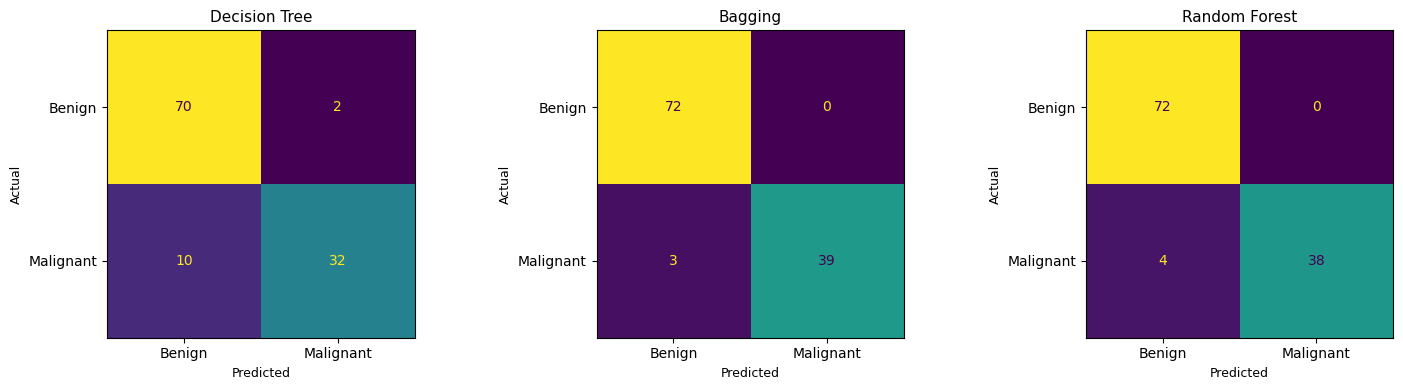

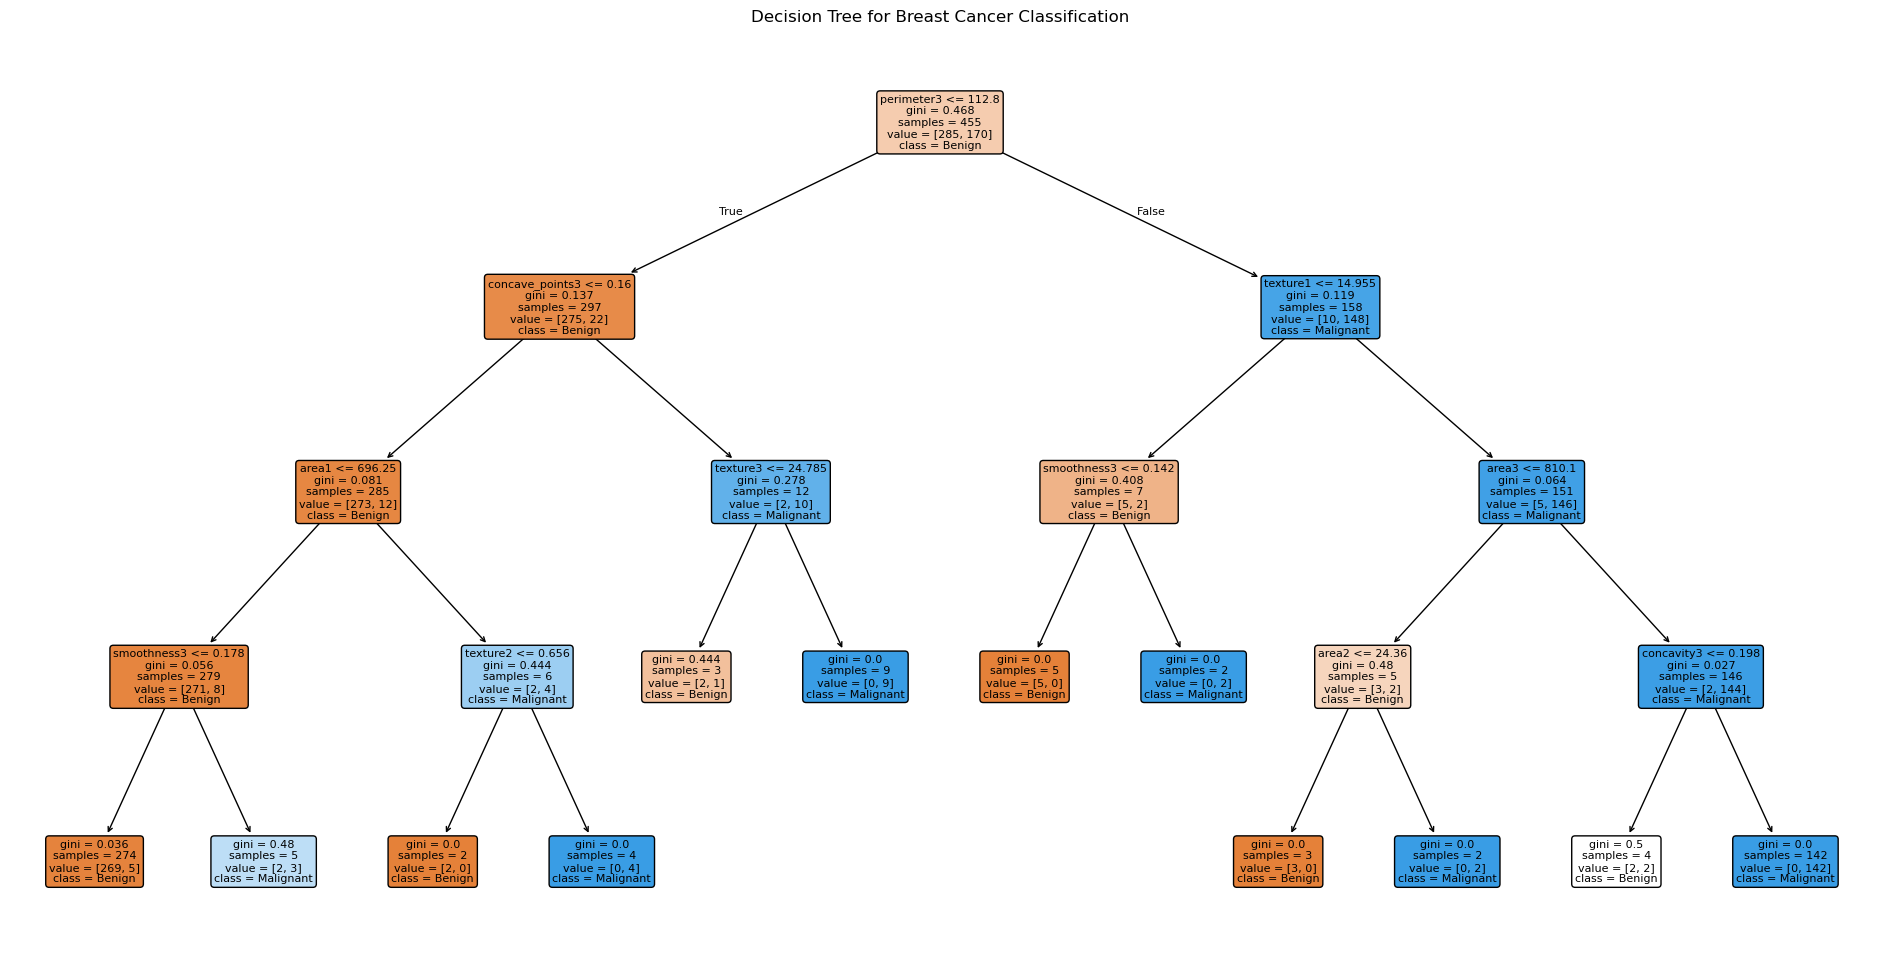


Top 10 Random Forest Important Features:
Worst Perimeter         0.147912
Worst Area              0.132269
Worst Concave Points    0.110114
Mean Concave Points     0.088200
Worst Radius            0.085116
Mean Radius             0.060554
Mean Perimeter          0.060465
Mean Area               0.044701
Mean Concavity          0.044091
Worst Concavity         0.032828
dtype: float64


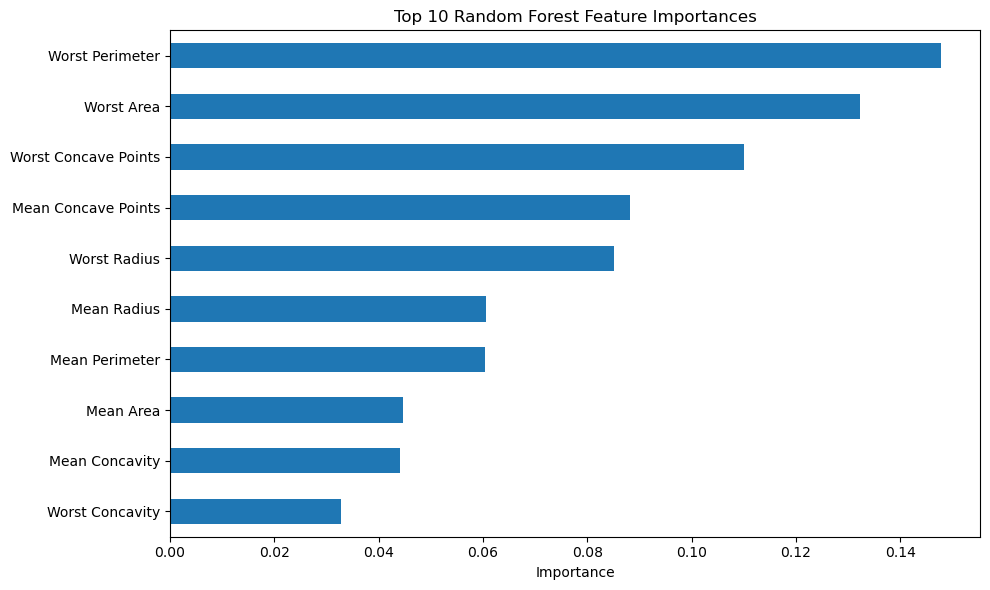

In [34]:
results_df = pd.DataFrame(results)
print("\nModel Performance Summary:")
print(results_df)

results_df.to_csv("model_results.csv", index=False)

print("\nDecision Tree Rules:")
print(export_text(dt, feature_names=list(X.columns)))

# =========================================================
# Combined confusion matrix figure (all 3 models in one)
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual", fontsize=9)

plt.tight_layout()
plt.savefig("fig2_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# Decision tree plot (leave as separate figure)
# =========================================================
plt.figure(figsize=(24, 12))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Benign", "Malignant"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree for Breast Cancer Classification")
plt.savefig("decision_tree_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# Random forest feature importance with better names
# =========================================================
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

def rename_feature(feature):
    if feature.endswith("1"):
        base = feature[:-1]
        return f"Mean {base.replace('_', ' ').title()}"
    elif feature.endswith("2"):
        base = feature[:-1]
        return f"Standard Error {base.replace('_', ' ').title()}"
    elif feature.endswith("3"):
        base = feature[:-1]
        return f"Worst {base.replace('_', ' ').title()}"
    else:
        return feature.replace('_', ' ').title()

rf_importance_named = rf_importance.copy()
rf_importance_named.index = [rename_feature(f) for f in rf_importance.index]

print("\nTop 10 Random Forest Important Features:")
print(rf_importance_named.head(10))

plt.figure(figsize=(10, 6))
rf_importance_named.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("fig3_rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()